# Lindblad Master Equation Solver: Core Implementation

This notebook introduces the mathematical framework of **Open Quantum Systems** and details the implementation of a custom **Lindblad Master Equation Solver** from scratch using NumPy and SciPy.

## 1. Mathematical Framework

Unlike closed quantum systems, which undergo unitary evolution governed by the Schrödinger equation, open quantum systems interact with their surrounding environment. This interaction leads to dissipation, decoherence, and energy relaxation, requiring a density matrix description $\rho$ rather than a state vector $|\psi\rangle$.

The time evolution of an open quantum system under the Markovian approximation is described by the **Lindblad Master Equation**:

$$\frac{d\rho}{dt} = -i[H, \rho] + \sum_{k} \gamma_k \left( L_k \rho L_k^\dagger - \frac{1}{2} \{L_k^\dagger L_k, \rho\} \right)$$

Where:
- $H$ is the system Hamiltonian.
- $L_k$ are the collapse (or jump) operators representing coupling to environmental noise channels.
- $\gamma_k \ge 0$ are the corresponding relaxation rates.
- $\{A, B\} = AB + BA$ is the anticommutator.

### Vectorization and the Liouvillian Superoperator
To solve this differential equation numerically, we vectorize the density matrix. A density matrix $\rho$ of dimension $n \times n$ is flattened into a column vector $|\rho\rangle\!\rangle$ of size $n^2 \times 1$. Under column-major (Fortran order, `order='F'`) vectorization, the Kronecker product $\otimes$ satisfies the identity:

$$\text{vec}(A \rho B) = (B^T \otimes A) \text{vec}(\rho) = (B^T \otimes A) |\rho\rangle\!\rangle$$

Applying this to the Lindblad equation yields a linear system of ordinary differential equations (ODEs):

$$\frac{d|\rho\rangle\!\rangle}{dt} = \mathcal{L} |\rho\rangle\!\rangle$$

Where $\mathcal{L}$ is the $n^2 \times n^2$ **Liouvillian superoperator**:

$$\mathcal{L} = -i (I \otimes H - H^T \otimes I) + \sum_k \gamma_k \left( L_k^* \otimes L_k - \frac{1}{2} I \otimes L_k^\dagger L_k - \frac{1}{2} (L_k^\dagger L_k)^T \otimes I \right)$$

Here, $L_k^*$ denotes the complex conjugate, and $L_k^\dagger$ denotes the conjugate transpose.

## 2. Implementation of Core Constants and Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.integrate import solve_ivp

# Ensure inline plotting
%matplotlib inline

def pauli_matrices():
    """Return the standard 2x2 Pauli matrices."""
    sx = np.array([[0, 1], [1, 0]], dtype=complex)
    sy = np.array([[0, -1j], [1j, 0]], dtype=complex)
    sz = np.array([[1, 0], [0, -1]], dtype=complex)
    return sx, sy, sz

def spin_operators():
    """Return the raising/lowering (ladder) operators for a two-level system."""
    sm = np.array([[0, 1], [0, 0]], dtype=complex) # |g><e|
    sp = np.array([[0, 0], [1, 0]], dtype=complex) # |e><g|
    return sm, sp

def bloch_vector(rho):
    """Compute the Bloch vector [x, y, z] for a given 2x2 density matrix."""
    sx, sy, sz = pauli_matrices()
    x = np.trace(rho @ sx).real
    y = np.trace(rho @ sy).real
    z = np.trace(rho @ sz).real
    return np.array([x, y, z])

## 3. Superoperator Builder

We now write `lindblad_superoperator` to construct $\mathcal{L}$ based on the system Hamiltonian $H$ and the list of collapse operators $L_k$ with rates $\gamma_k$.

In [2]:
def lindblad_superoperator(H, L_list=None, gamma_list=None):
    """Construct the Liouvillian superoperator matrix L in column-major vectorization."""
    n = H.shape[0]
    I = np.eye(n)

    # Unitary part: -i (I x H - H^T x I)
    L = -1j * (np.kron(I, H) - np.kron(H.T, I))

    # Dissipative part
    if L_list is not None:
        if gamma_list is None:
            gamma_list = [1.0] * len(L_list)
        for Lk, gk in zip(L_list, gamma_list):
            term1 = np.kron(Lk.conj(), Lk)                  # Lk* x Lk
            Lk_dag_Lk = Lk.conj().T @ Lk
            term2 = -0.5 * np.kron(I, Lk_dag_Lk)             # -0.5 * (I x Lk^dag Lk)
            term3 = -0.5 * np.kron(Lk_dag_Lk.T, I)           # -0.5 * ((Lk^dag Lk)^T x I)
            L += gk * (term1 + term2 + term3)

    return L

## 4. Time Evolution Solvers

We implement two numerical approaches to solve $\frac{d|\rho\rangle\!\rangle}{dt} = \mathcal{L} |\rho\rangle\!\rangle$:

1. **Matrix Exponential Method (`method='expm'`)**:
   $$|\rho(t)\rangle\!\rangle = e^{\mathcal{L} t} |\rho(0)\rangle\!\rangle$$
   This computes the matrix exponential directly for each time step. It is exact (up to numerical precision) for time-independent Liouvillians, but can be slow if a fine grid of time steps is required, since $e^{\mathcal{L} t}$ is evaluated repeatedly.

2. **ODE Integrator Method (`method='ode'`)**:
   Integrates the system of linear equations directly using standard Runge-Kutta solvers (`solve_ivp` with the high-order `DOP853` method). This is computationally efficient and generalizes well.

In [3]:
def lindblad_solve(H, rho0, tlist, L_list=None, gamma_list=None, method='expm'):
    """Solve the Lindblad Master Equation for a given timespan."""
    n = H.shape[0]
    L_op = lindblad_superoperator(H, L_list, gamma_list)
    rho0_vec = rho0.reshape(-1, order='F') # Column-major flattening

    if method == 'expm':
        rhos = []
        for t in tlist:
            rho_t_vec = expm(L_op * t) @ rho0_vec
            rho_t = rho_t_vec.reshape(n, n, order='F')
            rhos.append(rho_t)
        return np.array(rhos)

    elif method == 'ode':
        def drho_dt(t, rho_vec):
            return L_op @ rho_vec

        # Use DOP853 with very tight tolerances for precision
        sol = solve_ivp(drho_dt, [tlist[0], tlist[-1]], rho0_vec,
                        t_eval=tlist, method='DOP853', rtol=1e-12, atol=1e-14)
        rhos = np.array([v.reshape(n, n, order='F') for v in sol.y.T])
        return rhos

    else:
        raise ValueError(f"Unknown method: {method}")

## 5. Verification: Unitary Rabi Oscillations

Let's verify the solvers on a closed system (no noise collapse operators) undergoing Rabi oscillations.
Hamiltonian: $H = \frac{\Omega}{2} \sigma_x$ with drive strength $\Omega = 2\pi$.
Initial state: $|0\rangle = \begin{pmatrix} 1 \\ 0 \end{pmatrix}$, density matrix $\rho_0 = |0\rangle\langle 0|$.

In [4]:
Omega = 2.0 * np.pi
sx, sy, sz = pauli_matrices()
H = 0.5 * Omega * sx
rho0 = np.array([[1, 0], [0, 0]], dtype=complex) # |0><0|

tlist = np.linspace(0, 2.0, 200)

# Run both solvers
rhos_expm = lindblad_solve(H, rho0, tlist, method='expm')
rhos_ode = lindblad_solve(H, rho0, tlist, method='ode')

# Verify match
diff = np.max(np.abs(rhos_expm - rhos_ode))
print(f"Maximum numerical difference between expm and ode methods: {diff:.2e}")
assert diff < 1e-10

Maximum numerical difference between expm and ode methods: 8.62e-13


## 6. Visualization of Population and Coherences

We plot the ground and excited state populations ($P_0(t) = \rho_{00}(t)$ and $P_1(t) = \rho_{11}(t)$) along with coherence $|\rho_{01}(t)|$ to visualize the Rabi oscillations.

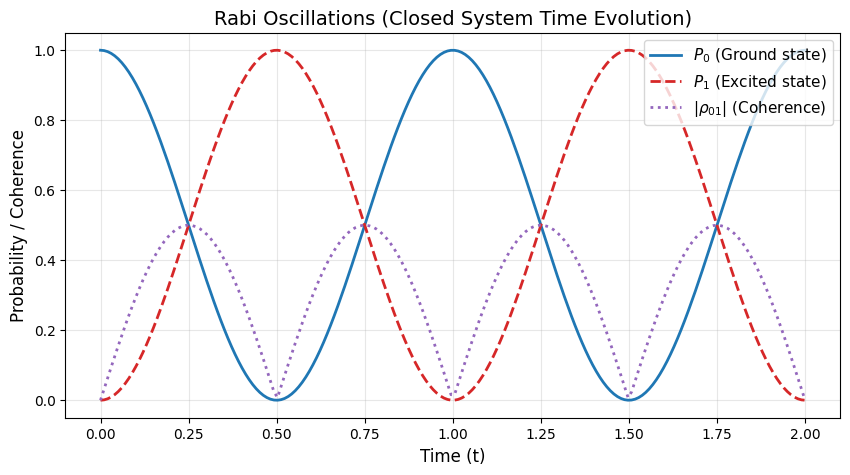

In [5]:
p0 = np.array([r[0, 0].real for r in rhos_ode])
p1 = np.array([r[1, 1].real for r in rhos_ode])
coherence = np.array([np.abs(r[0, 1]) for r in rhos_ode])

plt.figure(figsize=(10, 5))
plt.plot(tlist, p0, label=r'$P_0$ (Ground state)', color='#1f77b4', linewidth=2)
plt.plot(tlist, p1, label=r'$P_1$ (Excited state)', color='#d62728', linewidth=2, linestyle='--')
plt.plot(tlist, coherence, label=r'$|\rho_{01}|$ (Coherence)', color='#9467bd', linewidth=2, linestyle=':')
plt.xlabel('Time (t)', fontsize=12)
plt.ylabel('Probability / Coherence', fontsize=12)
plt.title('Rabi Oscillations (Closed System Time Evolution)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.show()